**CAS in Applied Data Science Final Project**

Coffee bean roasting is a critical process that significantly influences the quality, flavor, and physical properties of coffee beans. During roasting, moisture content changes dynamically as heat, environmental conditions, and processing parameters interact throughout the roasting cycle. Understanding and accurately predicting moisture behavior is important for optimizing roasting consistency, improving product quality, and enhancing process control in coffee production. In this project, data collected from a coffee machine are environmental variables, processing conditions, and roasting parameters. These variables are used to analyze the factors affecting moisture content during roasting. Exploratory Data Analysis (EDA) and supervised machine learning techniques are applied to model moisture dynamics and evaluate predictive performance. 

**Goals**
1. To evaluate and compare supervised machine learning models in order to identify the most robust approach for predicting coffee bean moisture content during roasting
2. To evaluate which factors affect the moisture dynamics during roasting




In [1]:
##Importing Libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


**Preprocessing**



In [2]:
#Reading the Dataset 
cols = [
    'time_index',
    'Moisture1',
    'Water',
    'Humidity_environment',
    'group',
    'weight',
    'Temperature_environment',
    'Recipe', 
    'Temperature1'
 ]

data = pd.read_csv('Dataset_Kabir.csv')

# Strip whitespace from column names
data.columns = data.columns.str.strip()

# Clean string columns and preserve group labels as text
data['group'] = data['group'].astype('string').str.strip().replace({'': pd.NA})
data['Recipe'] = data['Recipe'].astype('string').str.strip().replace({'': pd.NA})

# Fixing empty columns
new_data = data.dropna(subset=cols)
new_data['group'] = new_data['group'].astype('category')
new_data.head(5)

C:\Users\kabir\AppData\Local\Temp\ipykernel_10488\650399000.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['group'] = new_data['group'].astype('category')


,time_index,Moisture1,Water,Humidity_environment,group,weight,Temperature_environment,Recipe,Temperature1
2,04.01.2024 07:29,3.32,45.5,92.687,28871445,291.0,6.90,1.0,231.0
3,04.01.2024 07:46,3.32,45.5,93.993,28871445,291.0,6.78,1.0,231.0
4,04.01.2024 07:53,3.32,45.5,92.630,28871445,290.0,6.76,1.0,231.0
5,04.01.2024 08:04,3.47,45.5,93.674,28871445,290.0,6.68,1.0,231.0
7,04.01.2024 08:17,3.47,45.5,94.059,28871445,290.0,6.56,1.0,231.0


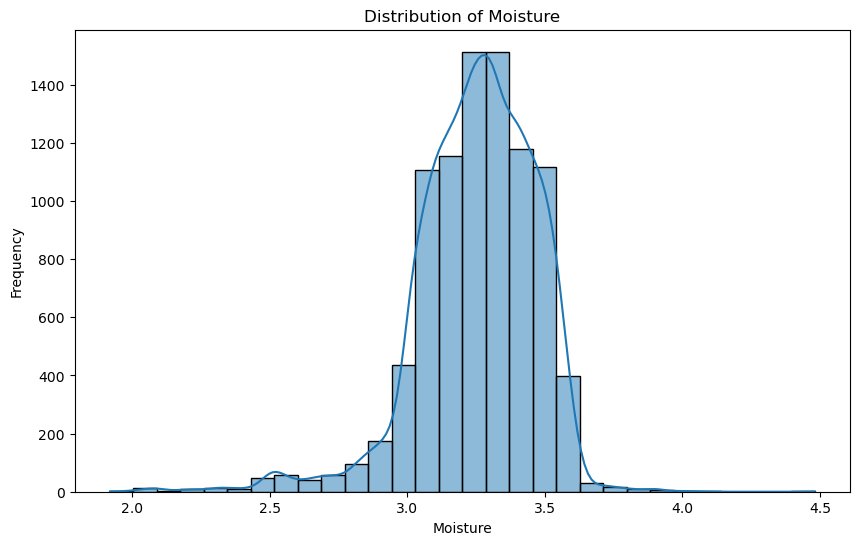

In [3]:
#Plottting Histogram for Moisture
plt.figure(figsize=(10,6))
sns.histplot(new_data['Moisture1'], bins=30, kde=True)
plt.title('Distribution of Moisture')
plt.xlabel('Moisture')
plt.ylabel('Frequency')
plt.show()

**Numerical Variables**

In [4]:
#Creating a summary table for the dataset
new_data.describe()

,Moisture1,Water,Humidity_environment,weight,Temperature_environment,Temperature1
count,9011.000000,9011.000000,9011.000000,9011.000000,9011.000000,9011.000000
mean,3.253889,45.174121,75.252928,288.287316,15.691703,206.132427
std,0.217269,2.058858,21.723469,6.321511,8.603261,68.084710
min,1.920000,30.000000,18.417000,54.000000,-5.420000,4.000000
25%,3.130000,44.100000,57.037500,289.000000,9.460000,224.900000
50%,3.270000,45.300000,79.875000,290.000000,14.770000,229.300000
75%,3.410000,46.500000,95.864000,291.000000,20.990000,231.100000
max,4.480000,58.000000,100.367000,458.000000,41.520000,237.800000


**Categorial Variables**

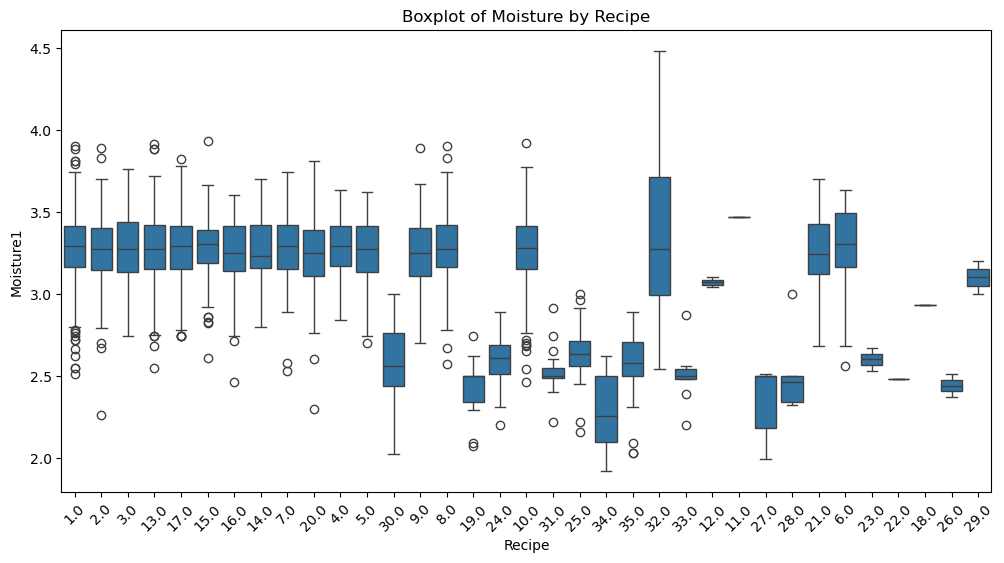

In [5]:
#Recipe and moisture boxplot
# The boxplot reveals whether certain roasting recipes are associated with higher or lower moisture levels, suggesting that recipe settings may influence moisture retention during roasting.
plot_data = new_data.loc[
    new_data['Recipe'].notna() &
    (new_data['Recipe'] != 'nan'),
:]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Recipe', y='Moisture1', data=plot_data)
plt.title('Boxplot of Moisture by Recipe')
plt.xlabel('Recipe')
plt.ylabel('Moisture1')
plt.xticks(rotation=45)
plt.show()

C:\Users\kabir\AppData\Local\Temp\ipykernel_10020\1540698068.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='group', y='Moisture1', data=new_data, ci=None, palette='viridis', order=order)
C:\Users\kabir\AppData\Local\Temp\ipykernel_10020\1540698068.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='group', y='Moisture1', data=new_data, ci=None, palette='viridis', order=order)


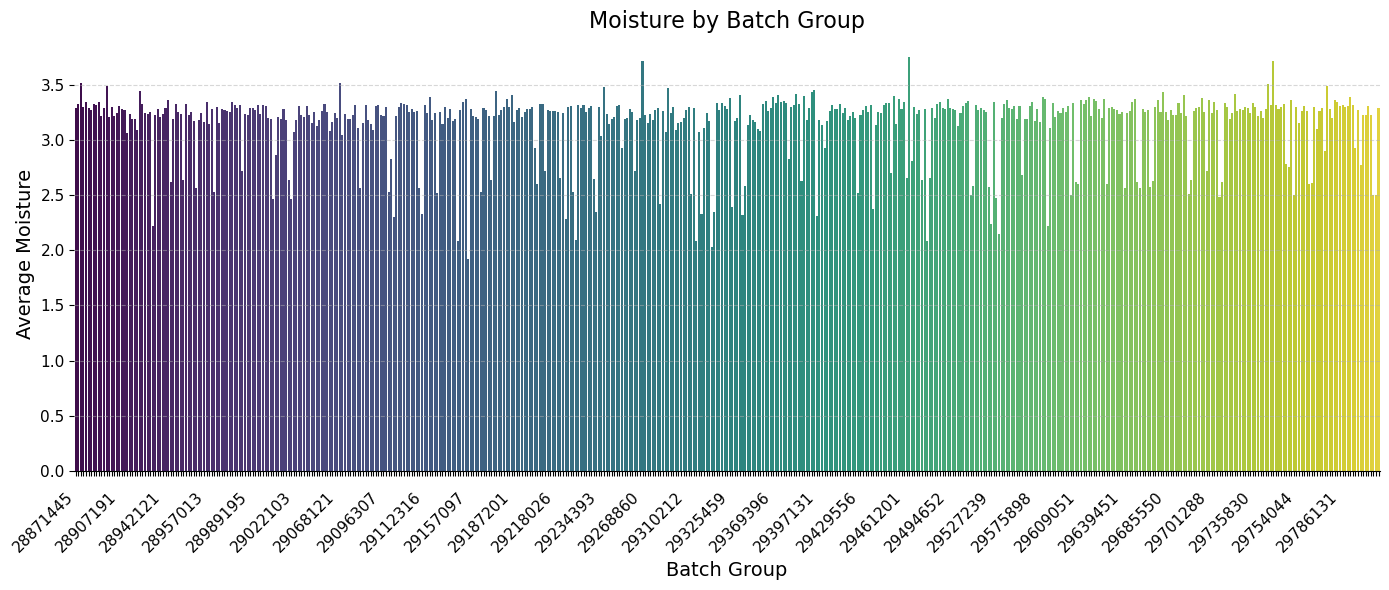

In [6]:
#Plotting the average moisture by batch group
plt.figure(figsize=(14,6))
# Explicit order as strings
order = list(new_data['group'].astype(str).unique())
ax = sns.barplot(x='group', y='Moisture1', data=new_data, ci=None, palette='viridis', order=order)
plt.title('Moisture by Batch Group', fontsize=16)
plt.xlabel('Batch Group', fontsize=14)
plt.ylabel('Average Moisture', fontsize=14)

# Compute bar centers for tick positions
patches = ax.patches
if patches:
    ticks = [p.get_x() + p.get_width() / 2.0 for p in patches]
else:
    ticks = list(range(len(order)))
ax.set_xticks(ticks)

# If many categories, thin the labels to avoid overlap
if len(order) > 30:
    step = int(np.ceil(len(order) / 30))
    labels = [lab if i % step == 0 else '' for i, lab in enumerate(order)]
else:
    labels = order

ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11, color='black')
ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', labelsize=11)

# Increase bottom margin so labels are visible
plt.subplots_adjust(bottom=0.55)
ax.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

**Time Dynamics**

C:\Users\kabir\AppData\Local\Temp\ipykernel_19308\3033323259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data['time_index_dt'] = pd.to_datetime(new_data['time_index'], dayfirst=True, errors='coerce')


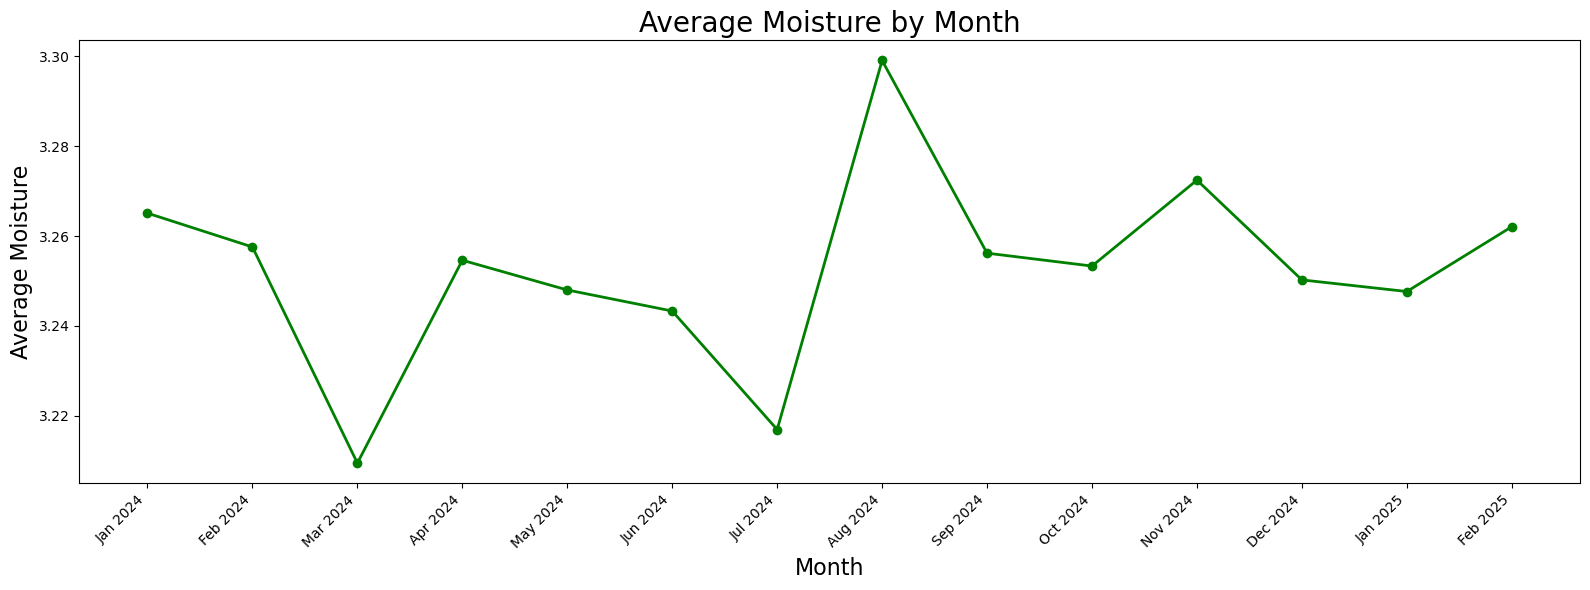

In [8]:
# Convert the time_index column to datetime if it isn’t already
new_data['time_index_dt'] = pd.to_datetime(new_data['time_index'], dayfirst=True, errors='coerce')
new_data = new_data.dropna(subset=['time_index_dt'])
new_data['time_index'] = new_data['time_index_dt'].astype('int64') // 10**9

# Plotting average moisture by month
new_data['month_year'] = new_data['time_index_dt'].dt.to_period('M').dt.to_timestamp()
moisture_by_month = new_data.groupby('month_year')['Moisture1'].mean()
month_labels = moisture_by_month.index.to_period('M').strftime('%b %Y')

plt.figure(figsize=(16,6))
plt.plot(month_labels, moisture_by_month.values, marker='o', color='green', linewidth=2)
plt.title('Average Moisture by Month', fontsize=20)
plt.xlabel('Month', fontsize=16)
plt.ylabel('Average Moisture', fontsize=16)
ax = plt.gca()
ax.set_xticks(range(len(month_labels)))
ax.set_xticklabels(month_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Feature Engineering**

**Machine Learning**
**Linear Regression**

In [28]:
# 2. FEATURES & TARGET
# =========================================================

X = new_data[
    [
        
        'Water',
        'Humidity_environment',
        'group',
        'weight',
        'Temperature_environment',
        'Recipe',
        'Temperature1'

        
        
        
        
    ]
]

y = new_data['Moisture1']


In [30]:
# 3. Train-Validation Split
# =========================================================
X_train, X_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)



In [31]:
# PREPROCESSING
# =========================================================

numeric_features = [
    
    'Water',
    'Humidity_environment',
    'weight',
    'Temperature_environment',
    'Temperature1'
]

categorical_features = [
    'Recipe',
    'group'
  
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)


In [32]:
# 5. LINEAR REGRESSION MODEL
# =========================================================

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])


In [33]:
#Fitting the model 
linear_pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Model Performance on Test Set:
MSE: 0.0371
RMSE: 0.1926
MAE: 0.1561
R²: 0.3263


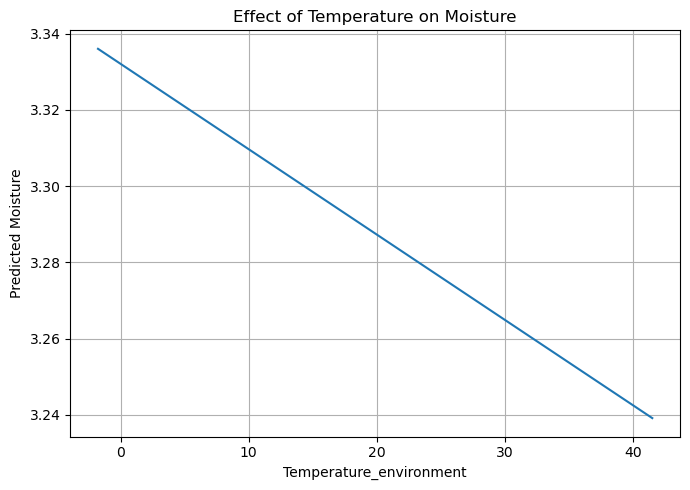

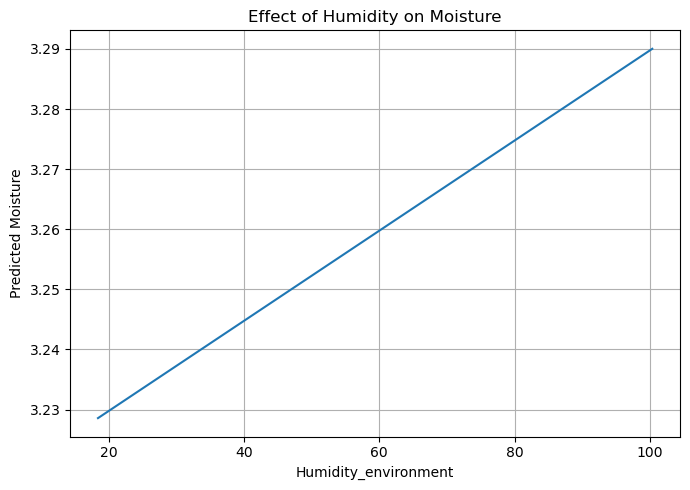

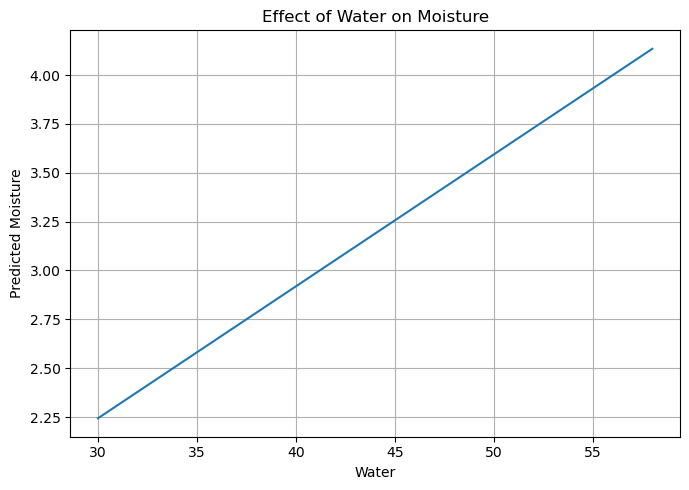

In [34]:
# 6. PREDICTION & EVALUATION
# =========================================================

y_pred = linear_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance on Test Set:")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# 7. SCENARIO ANALYSIS (ONE VARIABLE AT A TIME)
# =========================================================

n_scenarios = 10

# Base values
base = X_train.mean(numeric_only=True)

# ---------------- TEMPERATURE EFFECT ----------------
temp_range = np.linspace(
    X_train['Temperature_environment'].min(),
    X_train['Temperature_environment'].max(),
    n_scenarios
)

scenario_temp = pd.DataFrame({
    
    'Temperature_environment': temp_range,
    'Humidity_environment': base['Humidity_environment'],
    'Water': base['Water'],
    'weight': base['weight'],
    'Temperature1': base['Temperature1'],
    'Recipe': X_train['Recipe'].mode()[0],
    'group': X_train['group'].mode()[0]
})

scenario_temp['Predicted_Moisture'] = linear_pipeline.predict(scenario_temp)

# Plot
plt.figure(figsize=(7,5))
plt.plot(temp_range, scenario_temp['Predicted_Moisture'])
plt.xlabel('Temperature_environment')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Temperature on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- HUMIDITY EFFECT ----------------
humidity_range = np.linspace(
    X_train['Humidity_environment'].min(),
    X_train['Humidity_environment'].max(),
    n_scenarios
)

scenario_humidity = scenario_temp.copy()
scenario_humidity['Humidity_environment'] = humidity_range

scenario_humidity['Predicted_Moisture'] = linear_pipeline.predict(scenario_humidity)

plt.figure(figsize=(7,5))
plt.plot(humidity_range, scenario_humidity['Predicted_Moisture'])
plt.xlabel('Humidity_environment')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Humidity on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- WATER EFFECT ----------------
water_range = np.linspace(
    X_train['Water'].min(),
    X_train['Water'].max(),
    n_scenarios
)

scenario_water = scenario_temp.copy()
scenario_water['Water'] = water_range

scenario_water['Predicted_Moisture'] = linear_pipeline.predict(scenario_water)

plt.figure(figsize=(7,5))
plt.plot(water_range, scenario_water['Predicted_Moisture'])
plt.xlabel('Water')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Water on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

**Random Forest**

In [35]:
#Predicting moisture using Random Forest Regressor
RF = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [36]:
RF.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



Random Forest Model Performance on Test Set:
MSE: 0.0335
RMSE: 0.1829
MAE: 0.1486
R²: 0.3925


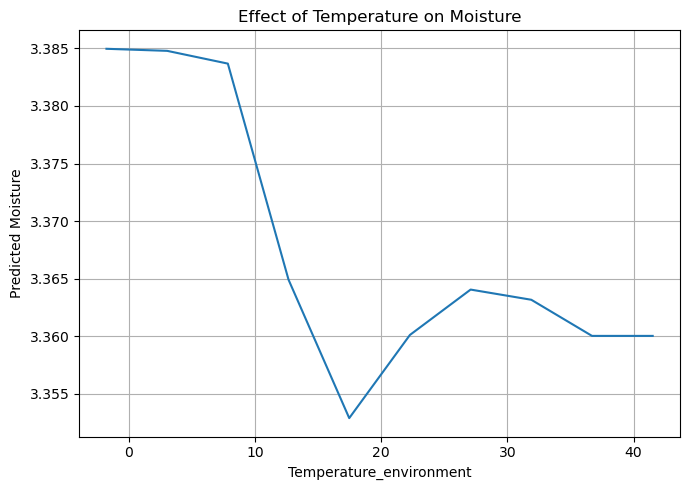

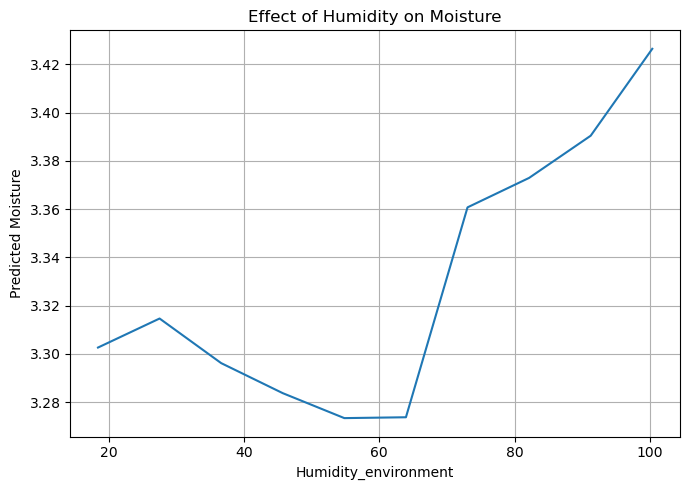

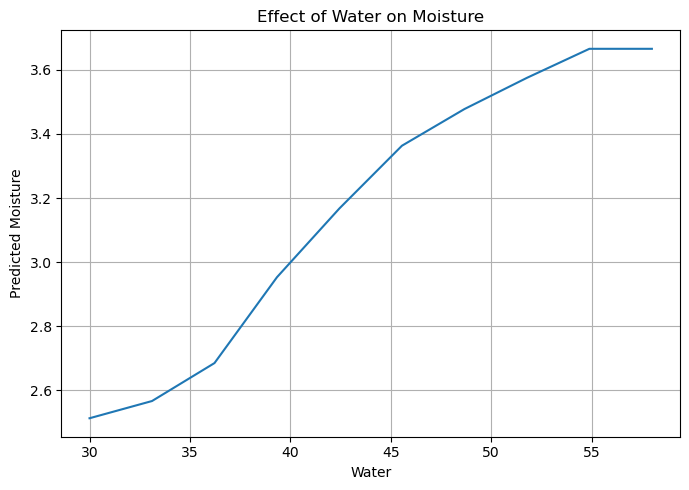

In [37]:
pred = RF.predict(X_test)

#Calculating performance metrics for Random Forest
mse_rf = mean_squared_error(y_test, pred)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, pred)
r2_rf = r2_score(y_test, pred)
print("\nRandom Forest Model Performance on Test Set:")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

# 7. SCENARIO ANALYSIS (ONE VARIABLE AT A TIME)
# =========================================================

n_scenarios = 10

# Base values
base = X_train.mean(numeric_only=True)

# ---------------- TEMPERATURE EFFECT ----------------
temp_range = np.linspace(
    X_train['Temperature_environment'].min(),
    X_train['Temperature_environment'].max(),
    n_scenarios
)

scenario_temp = pd.DataFrame({
    
    'Temperature_environment': temp_range,
    'Humidity_environment': base['Humidity_environment'],
    'Water': base['Water'],
    'weight': base['weight'],
    'Temperature1': base['Temperature1'],
    'Recipe': X_train['Recipe'].mode()[0],
    'group': X_train['group'].mode()[0]
})

scenario_temp['Predicted_Moisture'] = RF.predict(scenario_temp)

# Plot
plt.figure(figsize=(7,5))
plt.plot(temp_range, scenario_temp['Predicted_Moisture'])
plt.xlabel('Temperature_environment')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Temperature on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- HUMIDITY EFFECT ----------------
humidity_range = np.linspace(
    X_train['Humidity_environment'].min(),
    X_train['Humidity_environment'].max(),
    n_scenarios
)

scenario_humidity = scenario_temp.copy()
scenario_humidity['Humidity_environment'] = humidity_range

scenario_humidity['Predicted_Moisture'] = RF.predict(scenario_humidity)

plt.figure(figsize=(7,5))
plt.plot(humidity_range, scenario_humidity['Predicted_Moisture'])
plt.xlabel('Humidity_environment')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Humidity on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------- WATER EFFECT ----------------
water_range = np.linspace(
    X_train['Water'].min(),
    X_train['Water'].max(),
    n_scenarios
)

scenario_water = scenario_temp.copy()
scenario_water['Water'] = water_range

scenario_water['Predicted_Moisture'] = RF.predict(scenario_water)

plt.figure(figsize=(7,5))
plt.plot(water_range, scenario_water['Predicted_Moisture'])
plt.xlabel('Water')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Water on Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

**Feature Importance**

C:\Users\kabir\AppData\Local\Temp\ipykernel_19308\2232041545.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


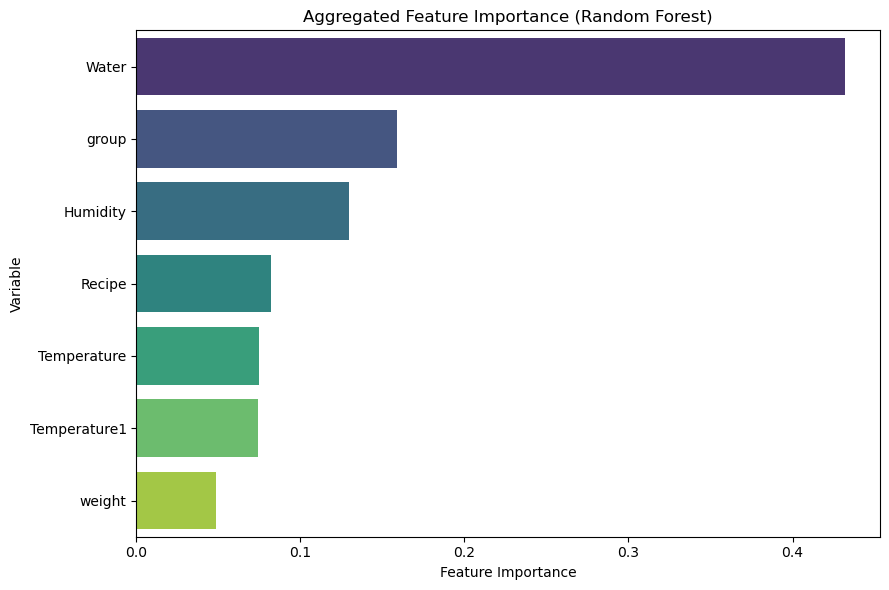

In [38]:
# **Feature Importance**


# ================================
# FEATURE IMPORTANCE EXTRACTION
# ================================
feature_names = (
    RF
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = RF.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'Variable': feature_names,
    'Feature_Importance': importances
})

# Clean variable names
imp_df['Variable'] = (
    imp_df['Variable']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

# Aggregate one-hot encoded variables
imp_df['Base_Variable'] = imp_df['Variable'].str.split('_').str[0]

aggregated_importance = (
    imp_df
    .groupby('Base_Variable', as_index=False)
    .agg(Feature_Importance=('Feature_Importance', 'sum'))
    .sort_values('Feature_Importance', ascending=False)
)

# Plot
plt.figure(figsize=(9,6))
sns.barplot(
    x='Feature_Importance',
    y='Base_Variable',
    data=aggregated_importance,
    palette='viridis'
)

plt.title('Aggregated Feature Importance (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

**XGBBoost**

In [39]:
#Defining the Pipeline for XGBoost Regressor
XGB = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    ))
])

In [40]:
#Fitting the model
XGB.fit(X_train, Y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
#Predicting on the validation set
pred = XGB.predict(X_test)


Scenario-Based Moisture Predictions:


,Water,Humidity_environment,Temperature_environment,Predicted_Moisture
0,30.00,18.42,-1.77,8.160000
1,33.11,27.52,3.04,8.130000
2,36.22,36.63,7.85,9.040000
3,39.33,45.73,12.66,8.980000
4,42.44,54.84,17.47,12.970000
5,45.56,63.94,22.28,18.690001
6,48.67,73.05,27.09,20.650000
7,51.78,82.16,31.90,28.049999
8,54.89,91.26,36.71,29.730000
9,58.00,100.37,41.52,29.580000


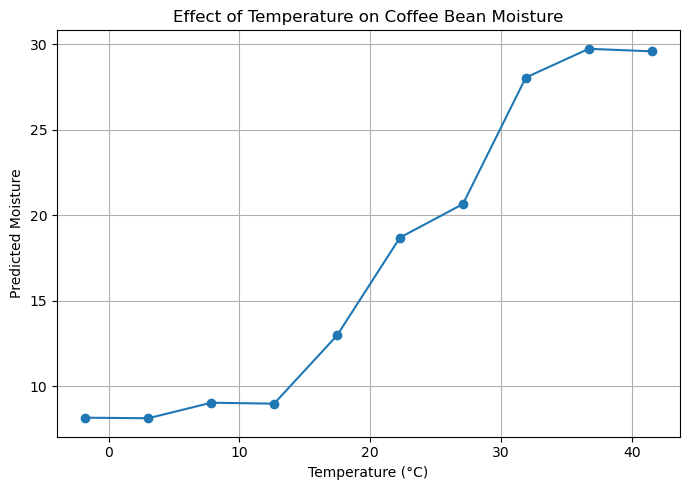

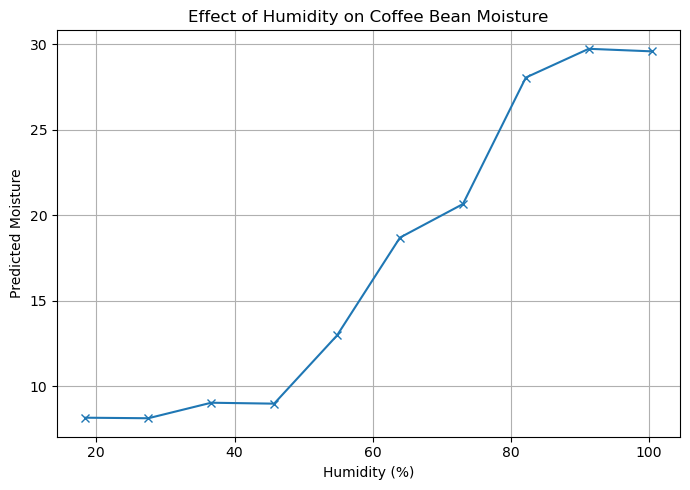

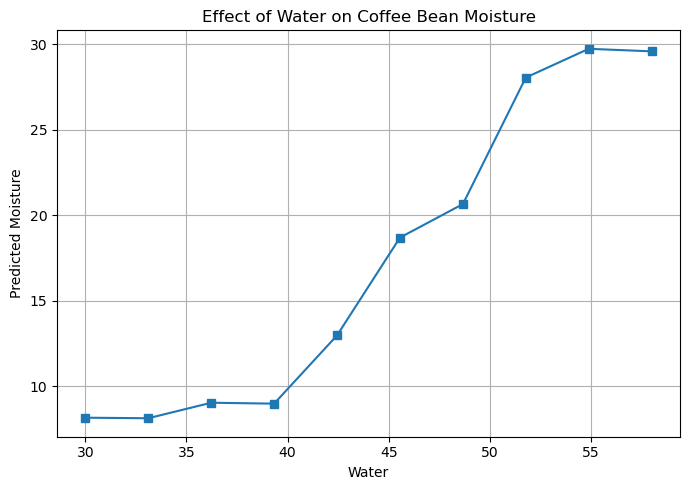

Model Performance on Test Set:


,Metric,Value
0,MSE,0.0331
1,RMSE,0.1819
2,MAE,0.1483
3,R²,0.3990


In [42]:
# Scenario Analysis
# ================================
n_scenarios = 10

# Create evenly spaced scenarios for Water, Temperature and Humidity

temperature_scenarios = np.linspace(
    X_train['Temperature_environment'].min(),
    X_train['Temperature_environment'].max(),
    n_scenarios
)

humidity_scenarios = np.linspace(
    X_train['Humidity_environment'].min(),
    X_train['Humidity_environment'].max(),
    n_scenarios
)

water_scenarios = np.linspace(
    X_train['Water'].min(),
    X_train['Water'].max(),
    n_scenarios
)


# Create scenario dataframe (same length)
scenario_df = pd.DataFrame({
    
    'Water': water_scenarios,
    'Humidity_environment': humidity_scenarios,
    'weight': np.full(n_scenarios, X_train['weight'].mean()),
    'Temperature_environment': temperature_scenarios,
    'Temperature1': np.full(n_scenarios, X_train['Temperature1'].mean()),
    'Recipe': np.full(n_scenarios, X_train['Recipe'].mode()[0]),
    'group': np.full(n_scenarios, X_train['group'].mode()[0]), 
  
})

# Predict moisture (back-transform from log scale)
scenario_df['Predicted_Moisture'] = np.expm1(
    XGB.predict(scenario_df)
)

# Display relevant columns
scenario_table = scenario_df[
    ['Water', 'Humidity_environment', 'Temperature_environment', 'Predicted_Moisture']
]



print("\nScenario-Based Moisture Predictions:")
display(scenario_table.round(2))

# ================================
# Plotting Scenario Results
# ================================
plt.figure(figsize=(7,5))
plt.plot(
    scenario_table['Temperature_environment'],
    scenario_table['Predicted_Moisture'],
    marker='o'
)
plt.xlabel('Temperature (°C)')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Temperature on Coffee Bean Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    scenario_table['Humidity_environment'],
    scenario_table['Predicted_Moisture'],
    marker='x'
)
plt.xlabel('Humidity (%)')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Humidity on Coffee Bean Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(
    scenario_table['Water'],
    scenario_table['Predicted_Moisture'],
    marker='s'
)
plt.xlabel('Water')
plt.ylabel('Predicted Moisture')
plt.title('Effect of Water on Coffee Bean Moisture')
plt.grid(True)
plt.tight_layout()
plt.show()


# ================================
# Evaluating Model Performance
# ================================
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)
mae = np.mean(np.abs(y_test - pred))

results_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Value': [mse, rmse, mae, r2]
})

print("Model Performance on Test Set:")
display(results_df.style.format({'Value': '{:.4f}'}))


C:\Users\kabir\AppData\Local\Temp\ipykernel_19308\4168836391.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


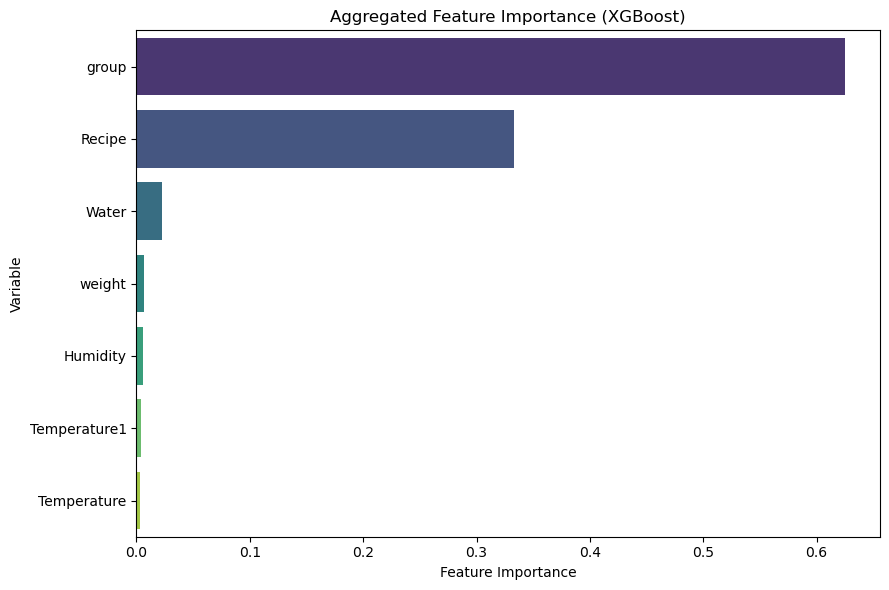

In [43]:
#Feature Importance for XGBoost 
feature_names = (
    XGB
    .named_steps['preprocessor']
    .get_feature_names_out()
)
importances = XGB.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({
    'Variable': feature_names,
    'Feature_Importance': importances
})
# Clean variable names
imp_df['Variable'] = (
    imp_df['Variable']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)
# Aggregate one-hot encoded variables
imp_df['Base_Variable'] = imp_df['Variable'].str.split('_').str[0]
aggregated_importance = (
    imp_df
    .groupby('Base_Variable', as_index=False)
    .agg(Feature_Importance=('Feature_Importance', 'sum'))
    .sort_values('Feature_Importance', ascending=False)
)
# Plot
plt.figure(figsize=(9,6))
sns.barplot(
    x='Feature_Importance',
    y='Base_Variable',
    data=aggregated_importance,
    palette='viridis'
)
plt.title('Aggregated Feature Importance (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()